# Beer Reviews — Final Project Part 3
**Authors:** Plinio Durango & Zachary M  
**Course:** BSDS 200 — Applied Data Science Methods

---

## 0. Database Connection

Every DataFrame in this notebook is the result of a SQL query executed against our local MySQL database (`final_project` schema) via SQLAlchemy. No CSV files are read here. This ensures the analysis is always consistent with the SQL work in `final_project.sql` and that we are working with the same cleaned, filtered data throughout.

We connect using the same credentials as MySQL Workbench: root, blank password, localhost:3306.

In [1]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

username = 'root'
password = quote_plus('')   # change if your password is not blank
host     = 'localhost'
port     = 3306
database = 'final_project'

engine = create_engine(
    f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}'
)

# Confirm connection and list tables
with engine.connect() as conn:
    result = conn.execute(text('SHOW TABLES;'))
    print('Tables in final_project:')
    for row in result:
        print(' ', row[0])

Tables in final_project:
  beers
  beers_clean
  beers_normalized
  bjcp_styles_clean


## 1. Load Data from SQL

We pull all beers from the `beers` table applying three filters directly in SQL:

- `ABV > 0` — removes rows where ABV is 0, which represents missing data (a genuine 0% alcohol beer would almost never appear in a craft beer review platform)
- `NOT (Min IBU = 0 AND Max IBU = 0)` — removes rows where both IBU columns are 0, which also represents missing data rather than a truly zero-bitterness beer
- `number_of_reviews > 25` — removes beers with too few reviews to produce a statistically reliable average rating. For example, a beer with 3 reviews where one reviewer happened to score it 5.0 would have an inflated average that does not reflect the true consensus opinion.

We also compute `IBU_mid = (Min IBU + Max IBU) / 2` directly in SQL as a single bitterness proxy, since the dataset stores a range rather than a single value.

In [2]:
# SQL query: pull main analysis dataset from beers_normalized
# Columns available in the view:
#   Name, Style, Brewery, ABV, IBU_mid
#   review_overall, review_taste, review_aroma, number_of_reviews
#   11 normalized flavor columns (_norm suffix)
# Note: review_appearance and review_palate are not in this view.
query_main = '''
SELECT
    Name,
    Style,
    Brewery,
    ABV,
    IBU_mid,
    astringency_norm, body_norm, alcohol_norm,
    bitter_norm, sweet_norm, sour_norm, salty_norm,
    fruits_norm, hoppy_norm, spices_norm, malty_norm,
    review_aroma,
    review_taste,
    review_overall,
    number_of_reviews
FROM beers_normalized
'''

with engine.connect() as conn:
    df = pd.read_sql(text(query_main), conn)

print(f'Rows loaded : {len(df):,}')
print(f'Columns     : {df.shape[1]}')
df.head(3)

Rows loaded : 2,224
Columns     : 20


,Name,Style,Brewery,ABV,IBU_mid,astringency_norm,body_norm,alcohol_norm,bitter_norm,sweet_norm,sour_norm,salty_norm,fruits_norm,hoppy_norm,spices_norm,malty_norm,review_aroma,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,5.3,37.5,0.1688,0.1828,0.0714,0.3132,0.3377,0.1369,0.0,0.1999,0.3312,0.0462,0.4642,3.498994,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,7.2,37.5,0.1558,0.3256,0.1428,0.2199,0.2510,0.0664,0.0,0.1454,0.2034,0.0693,0.3513,3.798337,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,5.0,37.5,0.1817,0.2113,0.0476,0.2799,0.1963,0.0456,0.0,0.0606,0.3138,0.0231,0.2593,3.409814,3.631300,3.830239,377


## 2. German Tank Problem — Normalizing Flavor Attributes

### Why the raw flavor scores are not directly comparable

The dataset contains 11 columns describing flavor and mouthfeel: `Astringency`, `Body`, `Alcohol`, `Bitter`, `Sweet`, `Sour`, `Salty`, `Fruits`, `Hoppy`, `Spices`, and `Malty`. These are **not ratings** on a fixed scale. They are raw word counts extracted from each beer's text description using NLP — the number of times a flavor-related word appeared in the description.

Because of this, each column has a completely different natural ceiling:
- `Malty` reaches up to **239** (malt vocabulary dominates beer writing)
- `Salty` only reaches **48** (the word 'salty' is rare in beer descriptions)

Comparing `Hoppy = 60` with `Malty = 60` is therefore meaningless — they represent different positions within their respective scales.

### The German Tank estimator

During World War II, Allied statisticians needed to estimate Germany's total tank production from a small sample of captured serial numbers. Their insight: if you observe **n** tanks with serial numbers up to **M** (the maximum in your sample), the best unbiased estimate of the true total population **N** is:

> **N_estimated = M x (n + 1) / n - 1**

We apply this formula independently to each flavor column. M is the highest word count observed in that column, and n is the number of beers in our filtered dataset. This gives us an estimated 'true maximum' for each attribute. Dividing every beer's raw score by that estimate produces a **0-1 normalized score**, making all 11 attributes directly comparable for the first time.

In [3]:
FLAVOR_COLS = [
    'Astringency', 'Body', 'Alcohol',
    'Bitter', 'Sweet', 'Sour', 'Salty',
    'Fruits', 'Hoppy', 'Spices', 'Malty'
]

# Compute German Tank estimates directly from the raw beers table.
# beers_normalized does not expose the raw columns, so we query
# beers here just to get the MAX values and n.
# This is the only query in the notebook that still uses beers.
query_tank = '''
SELECT
    COUNT(*)          AS n,
    MAX(Astringency)  AS m_Astringency,
    MAX(Body)         AS m_Body,
    MAX(Alcohol)      AS m_Alcohol,
    MAX(Bitter)       AS m_Bitter,
    MAX(Sweet)        AS m_Sweet,
    MAX(Sour)         AS m_Sour,
    MAX(Salty)        AS m_Salty,
    MAX(Fruits)       AS m_Fruits,
    MAX(Hoppy)        AS m_Hoppy,
    MAX(Spices)       AS m_Spices,
    MAX(Malty)        AS m_Malty
FROM beers
WHERE number_of_reviews > 25
  AND ABV > 0
  AND NOT (`Min IBU` = 0 AND `Max IBU` = 0)
'''

with engine.connect() as conn:
    stats = pd.read_sql(text(query_tank), conn).iloc[0]

n = int(stats['n'])
tank_estimates = {
    col: stats[f'm_{col}'] * (n + 1) / n
    for col in FLAVOR_COLS
}

FLAVOR_NORM = [c + '_norm' for c in FLAVOR_COLS]

# Summary table
import pandas as pd
summary = pd.DataFrame({
    'Observed Max'  : [int(stats[f'm_{c}']) for c in FLAVOR_COLS],
    'Tank Estimate' : [round(tank_estimates[c], 2) for c in FLAVOR_COLS],
    'Scale Factor'  : [round(1 / tank_estimates[c], 5) for c in FLAVOR_COLS]
}, index=FLAVOR_COLS)

print(f'Sample size n = {n:,}')
summary

Sample size n = 2,224


,Observed Max,Tank Estimate,Scale Factor
Astringency,77,77.03,0.01298
Body,175,175.08,0.00571
Alcohol,126,126.06,0.00793
Bitter,150,150.07,0.00666
Sweet,219,219.10,0.00456
Sour,241,241.11,0.00415
Salty,48,48.02,0.02082
Fruits,165,165.07,0.00606
Hoppy,172,172.08,0.00581
Spices,173,173.08,0.00578


## 3. Figure 1 — Distribution of Overall Review Scores

### What does a 'good beer' look like in this dataset?

Before exploring what makes beers great, we need to understand the baseline. BeerAdvocate uses a 0-5 scale, but in practice ratings cluster in the upper half because the platform is used primarily by craft beer enthusiasts who seek out interesting, high-quality beers. Very few beers score below 3.0, because low-quality mass-market beers rarely attract enough enthusiast reviews to pass our 25-review filter.

The **dashed line** marks the dataset mean. The **dotted line** marks 4.0, the threshold we use throughout the analysis to define 'top-rated' beers. Understanding where these boundaries fall in the distribution helps interpret every subsequent figure.

The SQL query pulls only the `review_overall` column with our standard filters applied.

Mean rating     : 3.765
Beers above 4.0 : 29.2%


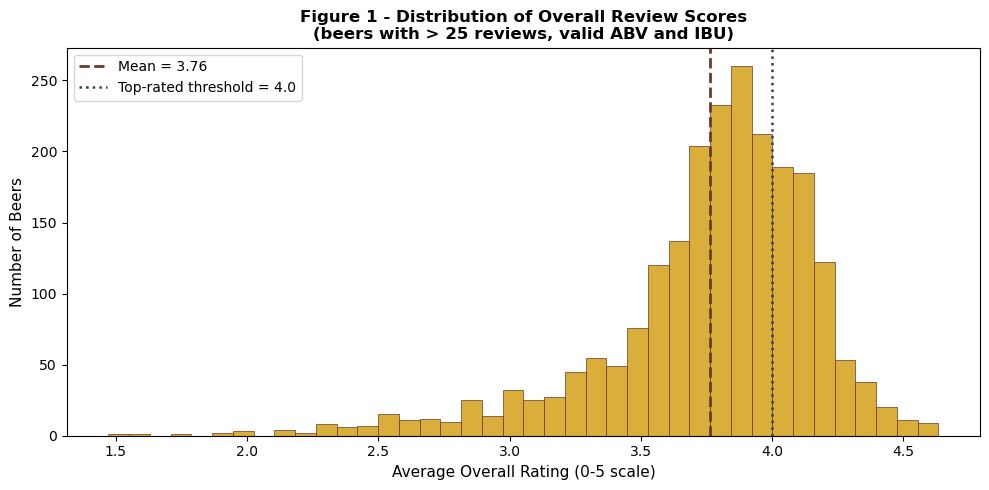

In [4]:
# SQL: pull review_overall for distribution plot
query_fig1 = '''
SELECT review_overall
FROM beers_normalized
'''

with engine.connect() as conn:
    df_fig1 = pd.read_sql(text(query_fig1), conn)

mean_val = df_fig1['review_overall'].mean()
pct_top  = (df_fig1['review_overall'] >= 4.0).mean() * 100
print(f'Mean rating     : {mean_val:.3f}')
print(f'Beers above 4.0 : {pct_top:.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_fig1['review_overall'], bins=40,
        color='#D4A017', edgecolor='#6B3A2A', linewidth=0.6, alpha=0.85)
ax.axvline(mean_val, color='#6B3A2A', lw=2, linestyle='--',
           label=f'Mean = {mean_val:.2f}')
ax.axvline(4.0, color='#2E4057', lw=1.8, linestyle=':',
           label='Top-rated threshold = 4.0')
ax.set_xlabel('Average Overall Rating (0-5 scale)', fontsize=11)
ax.set_ylabel('Number of Beers', fontsize=11)
ax.set_title('Figure 1 - Distribution of Overall Review Scores\n'
             '(beers with > 25 reviews, valid ABV and IBU)', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 4. Figure 2 — Top 15 Beer Styles by Average Rating

### Which styles do reviewers love most?

A beer's style is its most fundamental classification in craft brewing — it sets expectations for flavor, aroma, bitterness, alcohol content, and even serving temperature. Understanding which styles rank highest tells us whether reviewers favor bold, high-complexity specialty styles (like Imperial Stouts or American Wild Ales) or whether more accessible everyday styles can compete at the top.

We restrict to styles with **at least 5 beers** in the filtered dataset to prevent a single exceptional beer from inflating an entire style's average. For example, if only one Quadrupel passed our filters and it scored 4.8, that would not be a reliable signal about the style as a whole.

All grouping, filtering, and averaging happens inside MySQL via the SQL query below. Python only receives the final 15-row summary, which is the correct and efficient way to handle aggregation on large tables.

                           Style  beer_count  avg_overall  avg_taste  avg_aroma
                        Wild Ale          18        4.188      4.271      4.221
       Stout - American Imperial          28        4.164      4.335      4.272
                  IPA - American          30        4.116      4.094      4.070
                  IPA - Imperial          29        4.106      4.195      4.211
        Stout - Russian Imperial          32        4.103      4.203      4.138
Lager - Kellerbier / Zwickelbier           8        4.098      3.911      3.779
            Lambic - Traditional           5        4.097      4.135      4.185
             Pale Ale - American          22        4.069      3.937      3.897
          Farmhouse Ale - Saison          27        4.054      4.031      4.016
               Porter - Imperial          14        4.039      4.096      4.081
                 Lambic - Gueuze          18        4.030      4.042      4.035
                 Stout - Oatmeal        

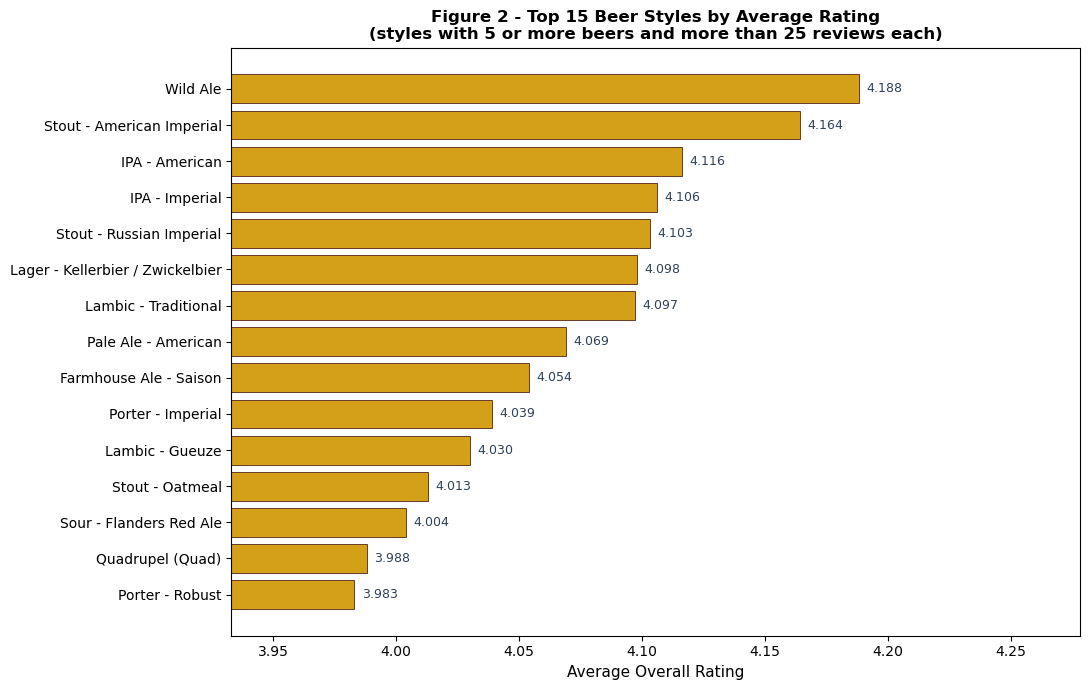

In [5]:
# SQL: average rating per style (top 15)
query_fig2 = '''
SELECT
    Style,
    COUNT(*)                          AS beer_count,
    ROUND(AVG(review_overall), 3)     AS avg_overall,
    ROUND(AVG(review_taste), 3)       AS avg_taste,
    ROUND(AVG(review_aroma), 3)       AS avg_aroma
FROM beers_normalized
GROUP BY Style
HAVING beer_count >= 5
ORDER BY avg_overall DESC
LIMIT 15
'''

with engine.connect() as conn:
    df_fig2 = pd.read_sql(text(query_fig2), conn)

print(df_fig2.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(df_fig2['Style'], df_fig2['avg_overall'],
               color='#D4A017', edgecolor='#6B3A2A', linewidth=0.7)
for bar, val in zip(bars, df_fig2['avg_overall']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9, color='#2E4057')
ax.set_xlabel('Average Overall Rating', fontsize=11)
ax.set_title('Figure 2 - Top 15 Beer Styles by Average Rating\n'
             '(styles with 5 or more beers and more than 25 reviews each)',
             fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(left=df_fig2['avg_overall'].min() - 0.05,
            right=df_fig2['avg_overall'].max() + 0.09)
plt.tight_layout()
plt.show()

## 5. Figure 3 — Flavor DNA Radar Chart (German Tank Normalized)

### What flavor profile separates great beers from average ones?

This is the methodological centerpiece of the project, combining the storytelling angle (the German Tank Problem) with the core analytical question. We split beers into two tiers and compare their flavor signatures:

- **Top-rated**: review_overall >= 4.0
- **Below-average**: review_overall < 3.7

For each tier, we compute the mean normalized score across all 11 flavor attributes. Because we applied the German Tank correction, every attribute is on a fair 0-1 scale. Without this correction, `Malty` (max 239) would visually dominate any chart over `Salty` (max 48), even if Salty contributed equally to what makes a beer great.

The **radar (spider) chart** is the ideal visualization here because it shows all 11 dimensions simultaneously, making it easy to see the complete shape of each tier's flavor profile rather than just isolated attributes.

The SQL query uses a `CASE WHEN` to split tiers and computes the normalized averages inline by dividing directly by the German Tank estimates — all inside MySQL, so Python only receives two rows of data.

       rating_tier  beer_count
Top-rated (>= 4.0)         649
         Below 3.7         718


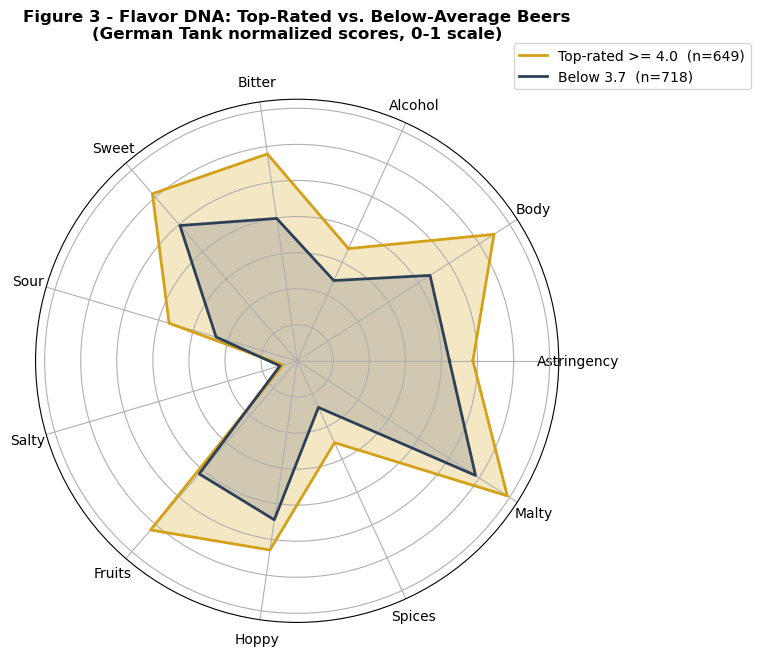

In [6]:
# SQL: normalized flavor averages per rating tier (top vs bottom)
# beers_normalized already has the _norm columns pre-computed,
# so we just AVG them directly — no division needed here.
flavor_sql = ',\n    '.join([
    f'ROUND(AVG({col}_norm), 4) AS {col}_norm'
    for col in FLAVOR_COLS
])

query_fig3 = f'''
SELECT
    CASE
        WHEN review_overall >= 4.0 THEN 'Top-rated (>= 4.0)'
        WHEN review_overall <  3.7 THEN 'Below 3.7'
        ELSE NULL
    END AS rating_tier,
    COUNT(*) AS beer_count,
    {flavor_sql}
FROM beers_normalized
WHERE (review_overall >= 4.0 OR review_overall < 3.7)
GROUP BY rating_tier
'''

with engine.connect() as conn:
    df_fig3 = pd.read_sql(text(query_fig3), conn)

print(df_fig3[['rating_tier', 'beer_count']].to_string(index=False))

# Extract values for radar
top_row    = df_fig3[df_fig3['rating_tier'] == 'Top-rated (>= 4.0)'].iloc[0]
bottom_row = df_fig3[df_fig3['rating_tier'] == 'Below 3.7'].iloc[0]
top_vals    = [top_row[c + '_norm']    for c in FLAVOR_COLS]
bottom_vals = [bottom_row[c + '_norm'] for c in FLAVOR_COLS]

# Close the polygon
N      = len(FLAVOR_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
top_vals    = top_vals    + [top_vals[0]]
bottom_vals = bottom_vals + [bottom_vals[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
n_top = int(top_row['beer_count'])
n_bot = int(bottom_row['beer_count'])
ax.plot(angles, top_vals,    color='#D4A017',  lw=2,
        label=f'Top-rated >= 4.0  (n={n_top:,})')
ax.fill(angles, top_vals,    color='#D4A017',  alpha=0.25)
ax.plot(angles, bottom_vals, color='#2E4057', lw=2,
        label=f'Below 3.7  (n={n_bot:,})')
ax.fill(angles, bottom_vals, color='#2E4057', alpha=0.18)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(FLAVOR_COLS, size=10)
ax.set_yticklabels([])
ax.set_title('Figure 3 - Flavor DNA: Top-Rated vs. Below-Average Beers\n'
             '(German Tank normalized scores, 0-1 scale)',
             y=1.10, fontweight='bold')
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12))
plt.tight_layout()
plt.show()

## 6. Figure 4 — ABV vs. Average Rating

### Does a stronger beer mean a better beer?

Alcohol by volume (ABV) is one of the most objective measurements in the dataset — a direct chemical property, not derived from text or reviewer opinion. A common belief in craft beer culture is that higher-ABV beers are more complex and therefore better rated. This makes intuitive sense: barleywines, imperial stouts, and quadrupels — all high-ABV styles — are known for their richness and depth.

However, there is a confounding factor worth considering: the BeerAdvocate reviewer base skews toward enthusiasts who specifically seek out bold, extreme beers. A high-ABV beer may score well not because alcohol itself improves quality, but because high-ABV styles attract more knowledgeable reviewers who rate generously.

We test this by bucketing beers into six ABV ranges using `CASE WHEN` in SQL and comparing average ratings per bucket. The **bar height** shows the average overall rating; the **blue line** tracks how many beers fall in each bucket — thin data means less reliable averages.

 label  beer_count  avg_overall  avg_taste
  < 4%          44        3.193      2.990
  4-6%        1025        3.662      3.515
  6-8%         586        3.870      3.857
 8-10%         336        3.874      3.936
10-14%         209        3.902      4.034
  14%+          24        3.915      4.207


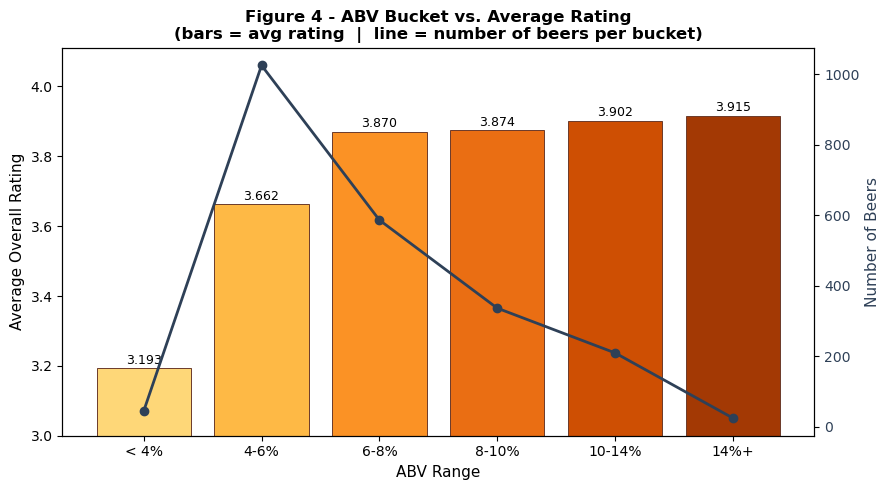

In [7]:
# SQL: ABV buckets vs. average rating
query_fig4 = '''
SELECT
    CASE
        WHEN ABV < 4  THEN '1. Under 4pct'
        WHEN ABV < 6  THEN '2. 4 to 6pct'
        WHEN ABV < 8  THEN '3. 6 to 8pct'
        WHEN ABV < 10 THEN '4. 8 to 10pct'
        WHEN ABV < 14 THEN '5. 10 to 14pct'
        ELSE               '6. 14pct and above'
    END                               AS abv_bucket,
    COUNT(*)                          AS beer_count,
    ROUND(AVG(review_overall), 3)     AS avg_overall,
    ROUND(AVG(review_taste),   3)     AS avg_taste
FROM beers_normalized
GROUP BY abv_bucket
ORDER BY abv_bucket
'''

with engine.connect() as conn:
    df_fig4 = pd.read_sql(text(query_fig4), conn)

# Map bucket codes to clean display labels
label_map_abv = {
    '1. Under 4pct':    '< 4%',
    '2. 4 to 6pct':     '4-6%',
    '3. 6 to 8pct':     '6-8%',
    '4. 8 to 10pct':    '8-10%',
    '5. 10 to 14pct':   '10-14%',
    '6. 14pct and above': '14%+'
}
df_fig4['label'] = df_fig4['abv_bucket'].map(label_map_abv)

print(df_fig4[['label','beer_count','avg_overall','avg_taste']].to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 5))
colors = [cm.YlOrBr(x) for x in np.linspace(0.3, 0.85, len(df_fig4))]
bars = ax1.bar(df_fig4['label'], df_fig4['avg_overall'],
               color=colors, edgecolor='#6B3A2A', linewidth=0.7)
for bar, val in zip(bars, df_fig4['avg_overall']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax2 = ax1.twinx()
ax2.plot(df_fig4['label'], df_fig4['beer_count'],
         color='#2E4057', marker='o', lw=2, label='Number of beers')
ax2.set_ylabel('Number of Beers', color='#2E4057', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#2E4057')
ax1.set_xlabel('ABV Range', fontsize=11)
ax1.set_ylabel('Average Overall Rating', fontsize=11)
ax1.set_title('Figure 4 - ABV Bucket vs. Average Rating\n'
              '(bars = avg rating  |  line = number of beers per bucket)',
              fontweight='bold')
ax1.set_ylim(bottom=3.0)
plt.tight_layout()
plt.show()

## 7. Figure 5 — IBU vs. Average Rating

### Does a more bitter beer mean a better-rated beer?

IBU (International Bitterness Units) is the most direct chemical measure of bitterness in beer. Like ABV, it is an objective measurement — not derived from reviewer opinion. Comparing IBU against ratings is a natural companion to the ABV analysis, because together they test whether the two main 'strength' dimensions of beer (alcohol and bitterness) independently predict quality.

We compute a midpoint IBU (`(Min IBU + Max IBU) / 2`) since the dataset stores a range rather than a single value, and bucket beers into five bitterness tiers. The secondary line tracks the number of beers in each bucket so we can see where the data becomes too thin to trust.

Unlike ABV — where ratings rise monotonically — bitterness shows a different pattern: ratings rise up to the 60–80 IBU range, then flatten. There appears to be a sweet spot for bitterness beyond which adding more does not improve scores.

label  beer_count  avg_overall  avg_taste  avg_bitter_norm
 < 20         334        3.579      3.443           0.1053
20-40        1429        3.755      3.689           0.2531
40-60         229        3.843      3.875           0.3578
60-80         170        4.027      4.105           0.4193
  80+          62        3.989      4.097           0.4330


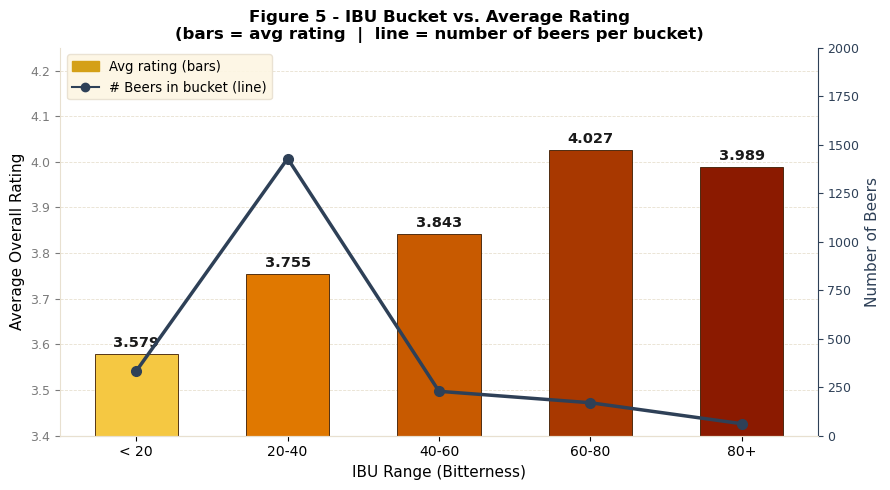

Peak rating at IBU bucket: 60-80  (4.027)
Unlike ABV, bitterness shows a sweet spot — ratings plateau above 60 IBU.


In [8]:
# SQL: IBU buckets vs. average rating
query_fig5_ibu = '''
SELECT
    CASE
        WHEN IBU_mid < 20  THEN '1. Under 20 IBU'
        WHEN IBU_mid < 40  THEN '2. 20 to 40 IBU'
        WHEN IBU_mid < 60  THEN '3. 40 to 60 IBU'
        WHEN IBU_mid < 80  THEN '4. 60 to 80 IBU'
        ELSE                    '5. 80+ IBU'
    END                    AS ibu_bucket,
    COUNT(*)                          AS beer_count,
    ROUND(AVG(review_overall), 3)     AS avg_overall,
    ROUND(AVG(review_taste),   3)     AS avg_taste,
    ROUND(AVG(bitter_norm), 4)        AS avg_bitter_norm
FROM beers_normalized
GROUP BY ibu_bucket
ORDER BY ibu_bucket
'''

with engine.connect() as conn:
    df_fig5 = pd.read_sql(text(query_fig5_ibu), conn)

# Map bucket codes to clean labels
label_map_ibu = {
    '1. Under 20 IBU': '< 20',
    '2. 20 to 40 IBU': '20-40',
    '3. 40 to 60 IBU': '40-60',
    '4. 60 to 80 IBU': '60-80',
    '5. 80+ IBU':      '80+'
}
df_fig5['label'] = df_fig5['ibu_bucket'].map(label_map_ibu)

print(df_fig5[['label','beer_count','avg_overall','avg_taste','avg_bitter_norm']].to_string(index=False))

fig, ax1 = plt.subplots(figsize=(9, 5))
colors_ibu = ['#F5C842', '#E07800', '#C85A00', '#A83800', '#8B1A00']
bars = ax1.bar(df_fig5['label'], df_fig5['avg_overall'],
               color=colors_ibu, edgecolor='#3A1A00', linewidth=0.6,
               width=0.55, zorder=2)
for bar, val in zip(bars, df_fig5['avg_overall']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.008,
             f'{val:.3f}', ha='center', va='bottom',
             fontsize=10.5, fontweight='bold', color='#1A1A1A')
ax1.set_ylim(3.4, 4.25)
ax1.set_ylabel('Average Overall Rating', fontsize=11)
ax1.set_xlabel('IBU Range (Bitterness)', fontsize=11)
ax1.tick_params(axis='y', labelsize=9, colors='#7A7A7A')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#E8E0D0')
ax1.spines['bottom'].set_color('#E8E0D0')
ax1.yaxis.grid(True, color='#E8E0D0', linewidth=0.6, linestyle='--', zorder=0)
ax1.set_axisbelow(True)

ax2 = ax1.twinx()
ax2.plot(df_fig5['label'], df_fig5['beer_count'],
         color='#2E4057', marker='o', markersize=7,
         lw=2.5, zorder=3)
ax2.set_ylabel('Number of Beers', color='#2E4057', fontsize=11)
ax2.tick_params(axis='y', labelsize=9, colors='#2E4057')
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_color('#E8E0D0')
ax2.spines['right'].set_color('#2E4057')
ax2.set_ylim(0, 2000)

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
bar_patch  = mpatches.Patch(color='#D4A017', label='Avg rating (bars)')
line_patch = mlines.Line2D([], [], color='#2E4057', marker='o',
                            markersize=6, label='# Beers in bucket (line)')
ax1.legend(handles=[bar_patch, line_patch], loc='upper left',
           fontsize=9.5, frameon=True, framealpha=0.9,
           facecolor='#FDF6E3', edgecolor='#E8E0D0')

ax1.set_title('Figure 5 - IBU Bucket vs. Average Rating\n'
              '(bars = avg rating  |  line = number of beers per bucket)',
              fontweight='bold')
plt.tight_layout()
plt.show()

# Annotation
peak_ibu = df_fig5.loc[df_fig5['avg_overall'].idxmax(), 'label']
peak_val = df_fig5['avg_overall'].max()
print(f'Peak rating at IBU bucket: {peak_ibu}  ({peak_val:.3f})')
print('Unlike ABV, bitterness shows a sweet spot — ratings plateau above 60 IBU.')

## 7. Figure 6 — Brewery Consistency: Average Rating and Full Range

### Which breweries are reliably excellent — and which are hit or miss?

A brewery's average rating is important, but it can be misleading on its own. A brewery averaging 4.2 could achieve this by consistently producing beers between 4.0 and 4.4, or by mixing 5-star masterpieces with 3.4-star disappointments. From a consumer perspective, these are very different breweries.

We define a simple consistency metric:

> **rating_range = MAX(review_overall) - MIN(review_overall)**

A small range means consistency. A large range means the brewery has both great and mediocre beers in the dataset.

The chart shows the **top 20 breweries by average rating**, requiring at least 3 beers with more than 25 reviews each (so the range is not determined by a single beer). Each **gold dot** is the average overall rating. The **grey horizontal bar** stretches from the lowest to the highest rated beer in that brewery's portfolio. The ideal brewery sits far to the right with a short bar — high average, high consistency. All grouping and range computation happens in MySQL.

                                                   Brewery  beers_in_portfolio  avg_overall  min_rating  max_rating  rating_range
Brouwerij Westvleteren (Sint-Sixtusabdij van Westvleteren)                   3        4.501       4.372       4.618         0.246
                                    Hill Farmstead Brewery                  12        4.289       3.984       4.483         0.498
                             Russian River Brewing Company                  16        4.269       3.954       4.600         0.646
                                     Surly Brewing Company                   9        4.254       4.062       4.431         0.368
                                    Brasserie de Rochefort                   3        4.236       4.137       4.339         0.202
                                       Brasserie Cantillon                  12        4.227       3.887       4.628         0.741
                                  Brouwerij Rodenbach N.V.                   3        4.21

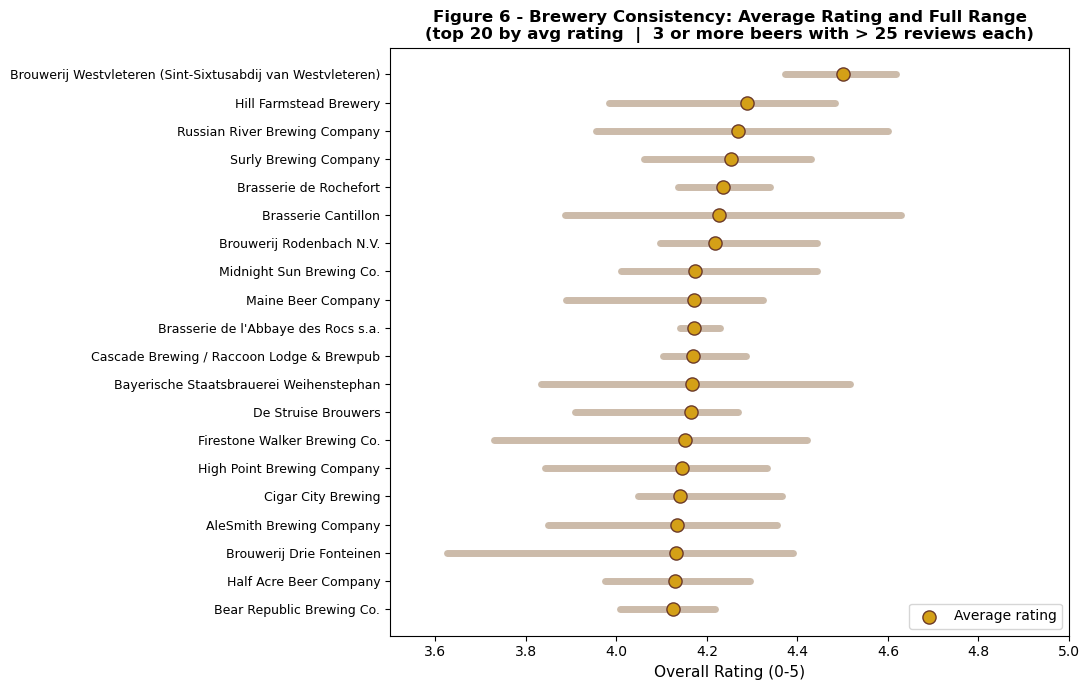

In [9]:
# SQL: brewery consistency (top 20 by avg rating, >= 3 beers)
query_fig6 = '''
SELECT
    Brewery,
    COUNT(*)                                           AS beers_in_portfolio,
    ROUND(AVG(review_overall), 3)                      AS avg_overall,
    ROUND(MIN(review_overall), 3)                      AS min_rating,
    ROUND(MAX(review_overall), 3)                      AS max_rating,
    ROUND(MAX(review_overall) - MIN(review_overall), 3) AS rating_range
FROM beers_normalized
GROUP BY Brewery
HAVING beers_in_portfolio >= 3
ORDER BY avg_overall DESC, rating_range ASC
LIMIT 20
'''

with engine.connect() as conn:
    df_fig6 = pd.read_sql(text(query_fig6), conn)

print(df_fig6.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
for i, (_, row) in enumerate(df_fig6.iterrows()):
    ax.plot([row['min_rating'], row['max_rating']], [i, i],
            color='#CCBBAA', lw=5, solid_capstyle='round', zorder=1)
ax.scatter(df_fig6['avg_overall'], range(len(df_fig6)),
           color='#D4A017', edgecolors='#6B3A2A', s=90, zorder=2,
           label='Average rating')
ax.set_yticks(range(len(df_fig6)))
ax.set_yticklabels(df_fig6['Brewery'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Overall Rating (0-5)', fontsize=11)
ax.set_title('Figure 6 - Brewery Consistency: Average Rating and Full Range\n'
             '(top 20 by avg rating  |  3 or more beers with > 25 reviews each)',
             fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(3.5, 5.0)
plt.tight_layout()
plt.show()